# Inverse Transform Method
## Generating Random Variables from Any Distribution

This notebook walks through the Inverse Transform Method, a core technique in quantitative finance and statistics that lets us sample from any probability distribution using only a uniform random number generator.

We will cover:
- How uniform random variables are generated from scratch
- The logic behind CDF inversion
- Discrete distributions — simulating a die roll
- Continuous distributions — the exponential distribution
- Finance application — modeling time between market orders

# Inverse Transform Method
## Generating Random Variables from Any Distribution

This notebook walks through the Inverse Transform Method, a core technique in quantitative finance and statistics that lets us sample from any probability distribution using only a uniform random number generator.

We will cover:
- How uniform random variables are generated from scratch
- The logic behind CDF inversion
- Discrete distributions, simulating a die roll
- Continuous distributions, the exponential distribution
- Finance application, modeling time between market orders


**Definition** (Probability density). Let $(\Omega, \mathcal{A}, \mu)$ be a measured space.

A function $f : \Omega \rightarrow \overline{\mathbb{R}}_+$ is called a **probability density** (with respect to $\mu$) if:
- $f$ is measurable
- $f$ is positive
- $\int_\Omega f \, d\mu = 1$

The **probability measure** $\mathbb{P}$ of density $f$ with respect to $\mu$, sometimes written $\mathbb{P} = f\mu$, is defined by:

$$\mathbb{P} : \mathcal{A} \rightarrow [0, 1]$$

$$A \mapsto \mathbb{P}(A) = \int_A f \, d\mu = \int_\Omega (f \mathbb{1}_A) \, d\mu$$

When $(\Omega, \mathcal{A}) = (\mathbb{R}, \mathcal{B}(\mathbb{R}))$ and $\mathbb{P} = f\lambda$ with respect to the Lebesgue measure $\lambda$, we say $\mathbb{P}$ is the **probability law of density** $f$.

**Example** — The **uniform distribution** on $[a, b]$, denoted $\mathcal{U}([a,b])$, is the law of density $f$ on $(\mathbb{R}, \mathcal{B}(\mathbb{R}))$ defined by:

$$\forall x \in \mathbb{R}, \quad f(x) = \frac{1}{b - a} \mathbb{1}_{[a,b]}(x)$$

## 1. Generating Uniform Random Variables

A **Uniform Random Variable** forms the foundation of the Inverse Transform Method.

A random variable $U$ follows the $\mathcal{U}([a, b])$ distribution if its probability density function is:

$$f(x) = \frac{1}{b - a} \mathbb{1}_{[a,b]}(x)$$

This means:
- $U$ takes values in $[a, b]$
- All intervals of equal length within $[a, b]$ are equally probable

In practice, we work with $U \sim \mathcal{U}([0, 1])$, where the density simplifies to $f(x) = 1$ on $[0, 1]$.

Computers cannot generate truly random numbers, instead they use a **Linear Congruential Generator (LCG)**, a deterministic algorithm that produces a sequence of pseudo-random integers:

$$X_{n+1} = (a \cdot X_n + c) \mod m$$

where:
- $X_0$ is the **seed** (starting value)
- $a$ is the **multiplier**
- $c$ is the **increment**
- $m$ is the **modulus**

Dividing by $m$ maps the output to $[0, 1)$, giving us our uniform random variable.

We can use np.random.uniform from Numpy to generate uniform random variables.


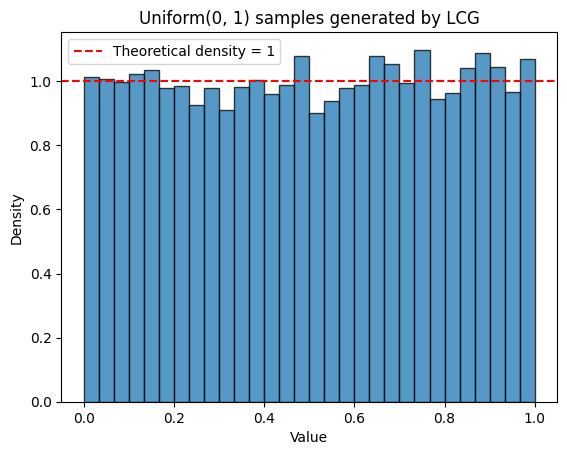

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def lcg(seed, a, c, m, n):

    samples = []
    x = seed
    for _ in range(n):
        x = (a * x + c) % m
        samples.append(x / m)
    return samples


seed = 42
a    = 1664525
c    = 1013904223
m    = 2**32

samples = lcg(seed, a, c, m, n=10000)

plt.hist(samples, bins=30, density=True, alpha=0.75, edgecolor='black')
plt.axhline(1, color='red', linestyle='--', label='Theoretical density = 1')
plt.title('Uniform(0, 1) samples generated by LCG')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


## 2. The Inverse Transform Method

The core idea is simple: if we know the CDF $F_X$ of a target distribution, 
we can generate samples from it using only $U \sim \mathcal{U}([0,1])$.

**Theorem.** Let $U \sim \mathcal{U}([0,1])$ and $F_X$ be a CDF. Then the random variable:

$$X = F_X^{-1}(U)$$

follows the distribution with CDF $F_X$.

**Why does this work?**

$$P(X \leq x) = P(F_X^{-1}(U) \leq x) = P(U \leq F_X(x)) = F_X(x)$$

Since $U$ is uniform, $P(U \leq t) = t$ for any $t \in [0,1]$.

**In practice, 3 steps:**
1. Draw $u \sim \mathcal{U}([0,1])$ using the LCG above
2. Compute $x = F_X^{-1}(u)$
3. $x$ is a sample from the target distribution

We apply this to a discrete distribution first, then a continuous one.


## 2.1. Continuous Case — Exponential Distribution

The exponential distribution models the **time between random events** — 
for example, the time between two market orders arriving on an exchange.

A random variable $X$ follows $\mathcal{E}(\lambda)$ if its density is:

$$f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Step 1 — Compute the CDF**

$$F_X(x) = \int_0^x \lambda e^{-\lambda t} \, dt = \Big[-e^{-\lambda t}\Big]_0^x = 1 - e^{-\lambda x}$$

**Step 2 — Invert the CDF**

We solve $u = F_X(x)$ for $x$:

$$u = 1 - e^{-\lambda x}$$
$$e^{-\lambda x} = 1 - u$$
$$-\lambda x = \ln(1 - u)$$
$$\boxed{F_X^{-1}(u) = -\frac{\ln(1-u)}{\lambda}}$$

**Step 3 — Apply the method**

Draw $U \sim \mathcal{U}([0,1])$ from our LCG, then:

$$X = -\frac{\ln(1 - U)}{\lambda} \sim \mathcal{E}(\lambda)$$


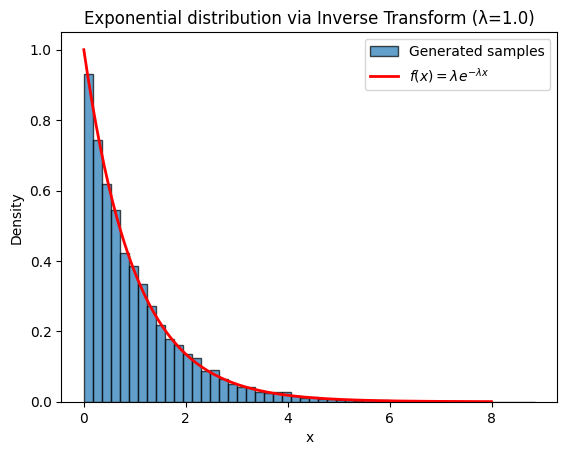

In [ ]:
def inverse_transform_exponential(lam, seed, n):
    
    # Step 1 generate uniform samples with our LCG
    uniform_samples = lcg(seed, a=1664525, c=1013904223, m=2**32, n=n)
    
    # Step 2 apply the inverse CDF: F^{-1}(u) = -ln(1-u) / lambda
    exponential_samples = [-np.log(1 - u) / lam for u in uniform_samples]
    
    return exponential_samples

# Parameters
lam  = 1.0   # lambda
n    = 10000

samples = inverse_transform_exponential(lam, seed=42, n=n)


x = np.linspace(0, 8, 200)
theoretical = lam * np.exp(-lam * x)

plt.hist(samples, bins=50, density=True, alpha=0.7, edgecolor='black', label='Generated samples')
plt.plot(x, theoretical, color='red', linewidth=2, label=r'$f(x) = \lambda e^{-\lambda x}$')
plt.title(f'Exponential distribution via Inverse Transform (λ={lam})')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()


## 2.2. Discrete Case — Simulating a Die Roll

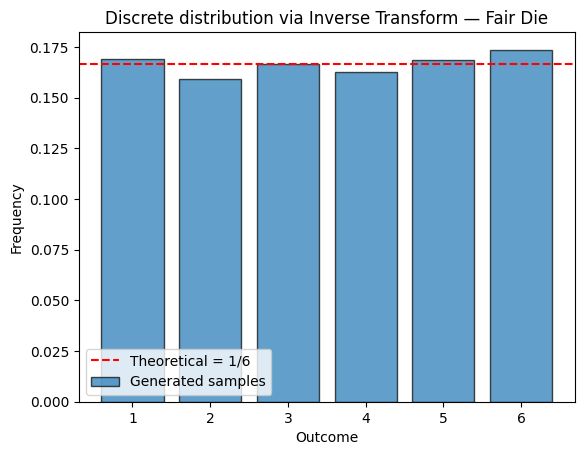

In [ ]:


# A fair die has 6 equally probable outcomes
outcomes     = [1, 2, 3, 4, 5, 6]
probabilities = [1/6] * 6


cdf = np.cumsum(probabilities)


def inverse_transform_discrete(outcomes, cdf, seed, n):
    """Generate discrete samples using the inverse transform method"""
    
    uniform_samples = lcg(seed, a=1664525, c=1013904223, m=2**32, n=n)
    
    
    results = []
    for u in uniform_samples:
        for i, cumulative_prob in enumerate(cdf):
            if u <= cumulative_prob:
                results.append(outcomes[i])
                break
    return results

samples = inverse_transform_discrete(outcomes, cdf, seed=42, n=10000)


plt.bar(outcomes, [samples.count(k)/len(samples) for k in outcomes],
        alpha=0.7, edgecolor='black', label='Generated samples')
plt.axhline(1/6, color='red', linestyle='--', label='Theoretical = 1/6')
plt.title('Discrete distribution via Inverse Transform, Fair Die')
plt.xlabel('Outcome')
plt.ylabel('Frequency')
plt.legend()
plt.show()
